In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sooniakbhatnagar/swiggy-restaurant-market-analysis/swiggy_file.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [3]:
plt.style.use('ggplot')

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sooniakbhatnagar/swiggy-restaurant-market-analysis/swiggy_file.csv') 
df.head()

,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,10+ ratings,₹250 for two,2,FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹69...,LALA LAJPAT RAI MARKET,No,Abohar
1,The Second Wife,"Indian, North Indian",3.6,50+ ratings,₹250 for two,2,"30% OFF UPTO ₹75\nUSE TRYNEWABOVE ₹149, FLAT ₹...",Central Abohar,No,Abohar
2,Tasty Bites,"Italian, Beverages",3.8,10+ ratings,₹200 for two,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar
3,Food Studio,"Pizzas, Burgers",3.5,8 ratings,₹49 for two,5,"50% OFF UPTO ₹100\nUSE TRYNEWABOVE ₹129, FLAT ...",Central Abohar,Yes,Abohar
4,Roll Express,"Fast Food, Snacks",4.3,100+ ratings,₹200 for two,2,DEAL OF DAY\n10% OFF UPTO ₹40\nUSE STEALDEALAB...,Circular Road,No,Abohar


In [5]:
print("Rows and Columns:", df.shape)

df.info()

df.describe(include='all')
df.columns

Rows and Columns: (140657, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140657 entries, 0 to 140656
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Restaurant Name    140657 non-null  object
 1   Cuisine            140630 non-null  object
 2   Rating             140657 non-null  object
 3   Number of Ratings  126115 non-null  object
 4   Average Price      140657 non-null  object
 5   Number of Offers   140657 non-null  int64 
 6   Offer Name         138849 non-null  object
 7   Area               140655 non-null  object
 8   Pure Veg           140657 non-null  object
 9   Location           140657 non-null  object
dtypes: int64(1), object(9)
memory usage: 10.7+ MB


Index(['Restaurant Name', 'Cuisine', 'Rating', 'Number of Ratings',
       'Average Price', 'Number of Offers', 'Offer Name', 'Area', 'Pure Veg',
       'Location'],
      dtype='object')

In [6]:
df.isnull().sum()

Restaurant Name          0
Cuisine                 27
Rating                   0
Number of Ratings    14542
Average Price            0
Number of Offers         0
Offer Name            1808
Area                     2
Pure Veg                 0
Location                 0
dtype: int64

In [7]:
df = df.drop_duplicates() 
print(df.shape)

(139321, 10)


In [8]:
df['Rating'] = pd.to_numeric( df['Rating'], errors='coerce' )

In [9]:
df['Review_Count'] = (df['Number of Ratings'] 
                      .astype(str) 
                      .str.extract(r'(\d+)')) 
df['Review_Count'] = pd.to_numeric( 
    df['Review_Count'][0], 
    errors='coerce')

In [10]:
df['Price'] = (df['Average Price'].astype(str) .str.extract(r'(\d+)'))
df['Price'] = pd.to_numeric(df['Price'][0], errors='coerce')

In [11]:
df['Number of Offers'] = pd.to_numeric(df['Number of Offers'], errors='coerce')

In [12]:
city_count = (df['Location'].value_counts().head(10))

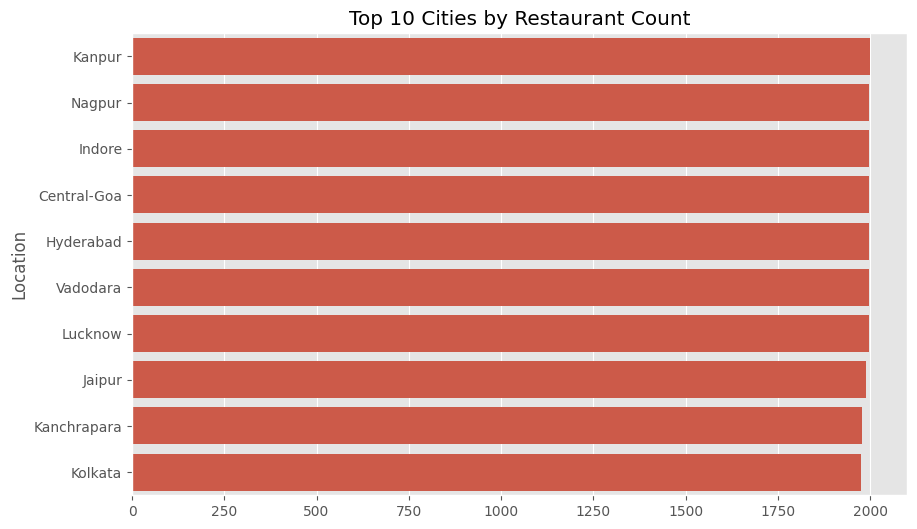

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=city_count.values, y=city_count.index) 
plt.title('Top 10 Cities by Restaurant Count') 
plt.show()

In [14]:
cuisines = (df['Cuisine'].str.split(',').explode().str.strip())
top_cuisines = (cuisines.value_counts().head(15))

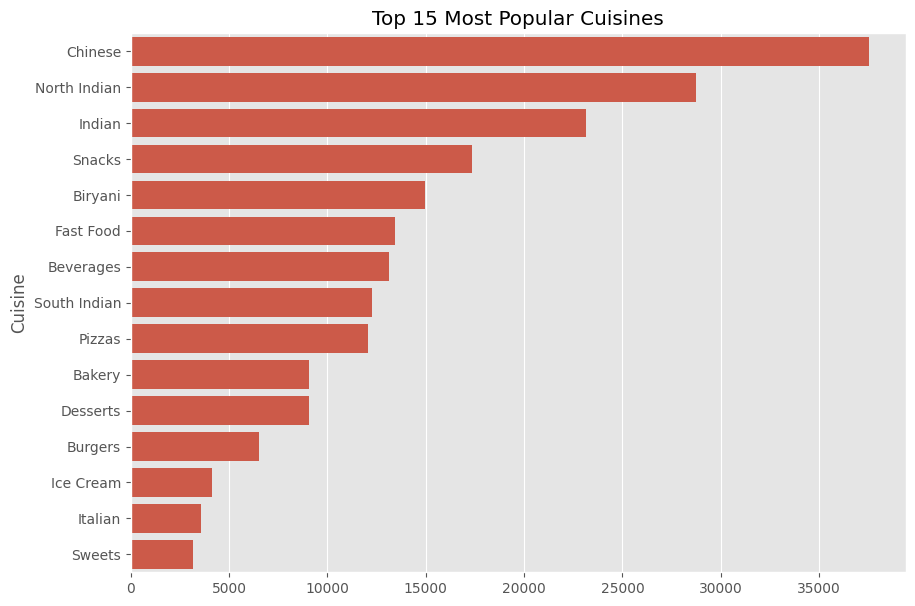

In [15]:
plt.figure(figsize=(10,7)) 
sns.barplot(x=top_cuisines.values,y=top_cuisines.index)
plt.title('Top 15 Most Popular Cuisines') 
plt.show()

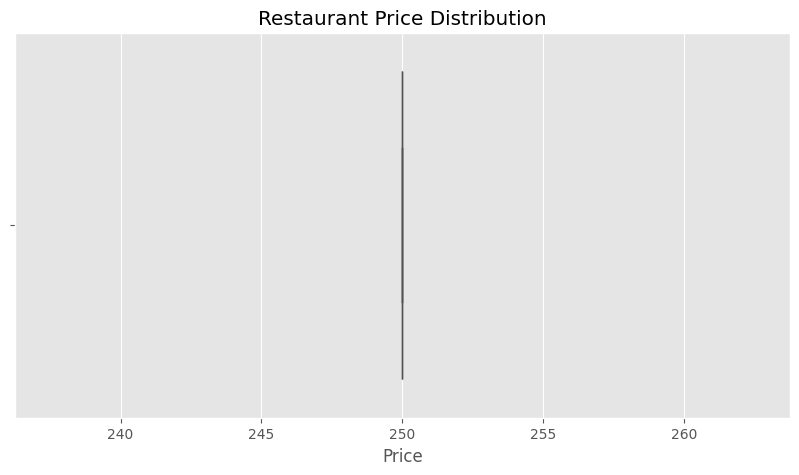

In [16]:
plt.figure(figsize=(10,5)) 
sns.boxplot( x=df['Price']) 
plt.title('Restaurant Price Distribution') 
plt.show()

In [17]:
offer_rating = (df.groupby('Number of Offers')['Rating'].mean().reset_index()) 
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

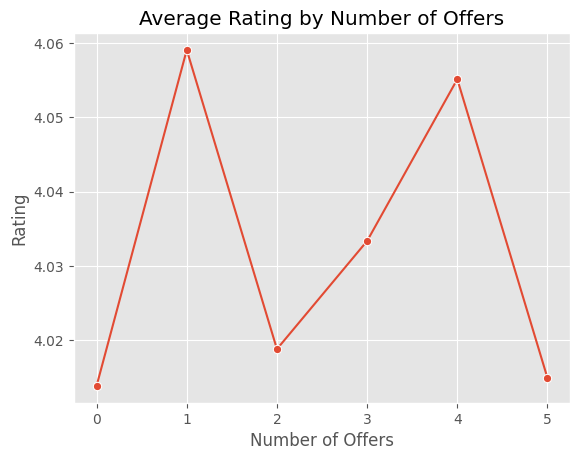

In [18]:
sns.lineplot(data=offer_rating, x='Number of Offers', y='Rating', marker='o') 
plt.title('Average Rating by Number of Offers') 
plt.show()

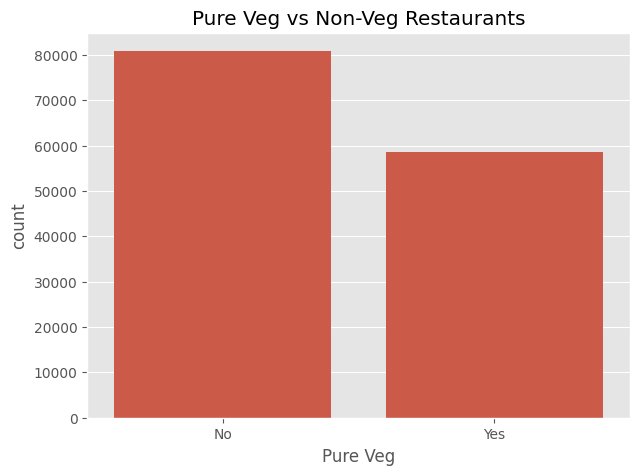

In [19]:
plt.figure(figsize=(7,5)) 
sns.countplot(data=df, x='Pure Veg') 
plt.title('Pure Veg vs Non-Veg Restaurants') 
plt.show()

In [20]:
top_restaurants = (df[df['Review_Count'] > 100].sort_values(by='Rating',ascending=False )) 
top_restaurants[['Restaurant Name', 'Rating', 'Review_Count']].head(10)

,Restaurant Name,Rating,Review_Count


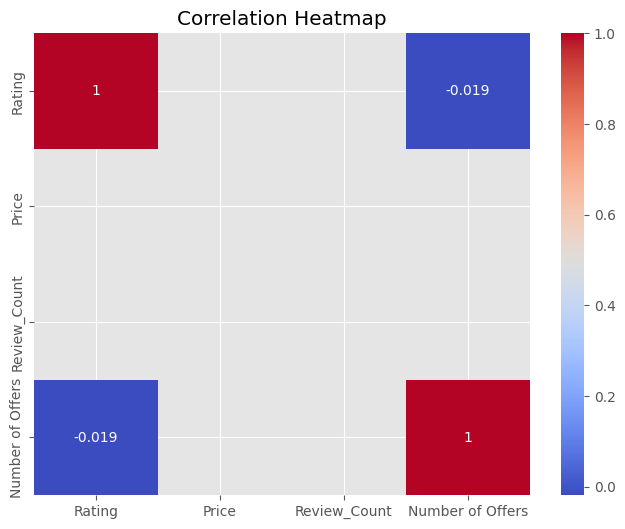

In [21]:
corr_df = df[['Rating','Price','Review_Count','Number of Offers']] 
plt.figure(figsize=(8,6)) 
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm') 
plt.title('Correlation Heatmap') 
plt.show()

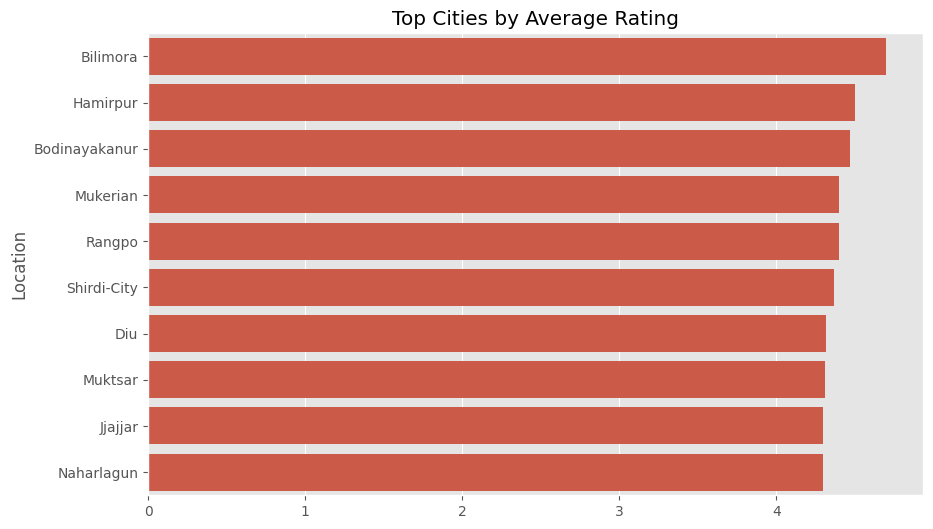

In [22]:
city_rating = (df.groupby('Location')['Rating'].mean().sort_values(ascending=False).head(10)) 
plt.figure(figsize=(10,6)) 
sns.barplot(x=city_rating.values, y=city_rating.index) 
plt.title('Top Cities by Average Rating') 
plt.show()

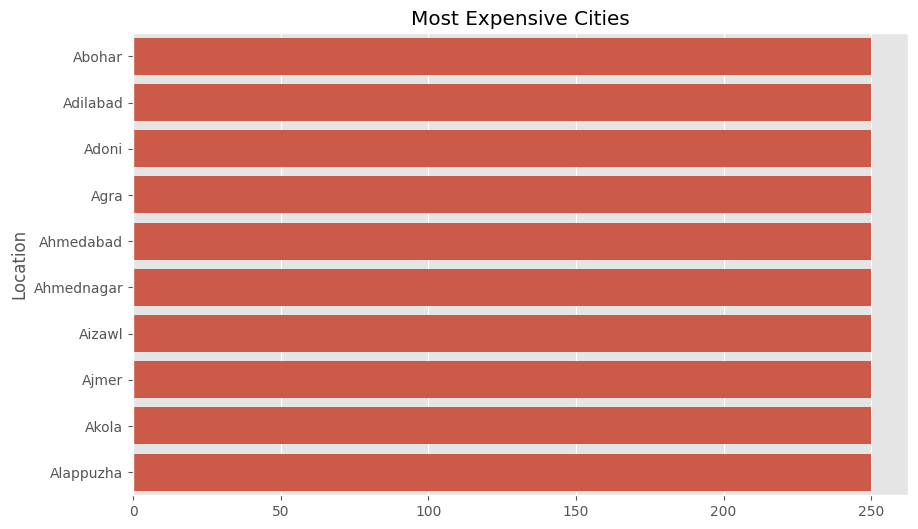

In [23]:
city_price = (df.groupby('Location')['Price'].mean().sort_values(ascending=False).head(10)) 
plt.figure(figsize=(10,6)) 
sns.barplot(x=city_price.values, y=city_price.index) 
plt.title('Most Expensive Cities') 
plt.show()

This project analyzed restaurant listings across India using Swiggy data. The study identified cuisine trends, customer preferences, pricing patterns, city-level competition, and restaurant performance metrics through exploratory data analysis and visualization.

Business Insights
Which city has the largest restaurant presence?
Which cuisine dominates Swiggy?
Do higher prices lead to higher ratings?
Do offers improve ratings?
Which cities have the highest-rated restaurants?
What percentage of restaurants are Pure Veg?
Which restaurants combine high ratings and high review counts?